In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: C:\Users\jmora\Documents\TFMDS


In [3]:
import pandas as pd
import numpy as np
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# Importar funciones personalizadas
from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)

## Lectura de fichero y adaptación de los tipos


In [4]:
df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())


Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idSecuencia         625800 non-null  datetime64[ns]
 1   producto            625800 non-null  int64         
 2   udsVenta            625800 non-null  int64         
 3   bolPromocion        625800 non-null  int64         
 4   bolOpen             625800 non-null  int64         
 5   bolHoliday          625800 non-null  int64         
 6   udsStock            625800 non-null  int64         
 7   rotura_stock        625800 non-null  bool          
 8   dia_semana          625800 non-null  int64         
 9   mes                 625800 non-null  int64         
 10  trimestre           625800 non-null  int64         
 11  semana              625800 non-null  int64         
 12  lag_ventas_1        625800 non-null  fl

# Random Forests (RF)

El algoritmo **Random Forest** (RF) es un método de **aprendizaje de conjunto (ensemble)** que construye y combina resultados de múltiples árboles de decisión.

1. **Generación de Múltiples Árboles (Bagging):** Cada árbol se entrena sobre un subconjunto de datos diferente utilizando la técnica de **Bagging** (Bootstrap Aggregating). Esto implica tomar **muestras repetidas con reemplazo** del conjunto de entrenamiento original (muestreo *bootstrap*).

2. **Decorrelación (Aleatoriedad de Características):** Para garantizar que los árboles no estén correlacionados (sean *decorrelacionados*), en cada paso de división (*split*) del árbol, el algoritmo considera solo un **subconjunto aleatorio de las características** disponibles para encontrar la mejor división. Esta doble aleatoriedad (en datos y en características) ayuda a reducir la **varianza**.

3. **Obtención del Resultado Final:** Una vez entrenados todos los árboles del "bosque" ($M$ árboles), el resultado final se obtiene:
    *   Para problemas de **Regresión** (predicción de series temporales), se obtiene **promediando** las salidas de todos los árboles.
    *   Para problemas de **Clasificación**, se obtiene por **votación mayoritaria**.

Este método es popular ya que es difícil que sufra de sobreajuste (*overfitting*) y aumenta la solidez de la predicción.




# Preparación de datos

In [5]:
# Eliminar días que la tienda está cerrada bolOpne == 0 ya que en modelos tipo Random Forest no aportan nada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()

In [6]:
# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'semana',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'media_mes_anterior', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

# ============================================================================
# LISTA PARA ALMACENAR TODAS LAS MÉTRICAS
# ============================================================================
todas_metricas = []  # ← Lista global para todas las métricas

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE RANDOM FOREST")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE RANDOM FOREST


# Random Forest global
modelo sobre todas la fechas y productos
Se va utilizar Optuna para buscar los mejores hiperparámetros.
Estos parámetros se utilizarán en los próximos modelos de Random Forest para cluster y productos, se asume que posiblemente serán los mismos parámetros, no se palntea utilizar optuna en el resto de modelos por el coste de tiempo que lleva

In [7]:
# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 1: RANDOM FOREST GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")



📍 MODELO 1: RANDOM FOREST GLOBAL

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)


In [8]:
print("\n🔍 Búsqueda de hiperparámetros con Optuna...")

# =====================================================
#  FUNCION OBJETIVO OPTUNA PARA RANDOM FOREST
# =====================================================

def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 4, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    mse = mean_squared_error(y_val, preds)
    return mse

tscv = TimeSeriesSplit(n_splits=2)

# =====================================================
# EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para Random Forest...")
start_time = time.perf_counter()

study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=5, n_jobs=-1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🌲 Mejores hiperparámetros RANDOM FOREST:")
print(study_rf.best_params)


[I 2025-12-01 23:00:14,490] A new study created in memory with name: no-name-75601b59-499a-40bd-9efb-4ce70342087b



🔍 Búsqueda de hiperparámetros con Optuna...

🔍 Iniciando optimización de hiperparámetros con Optuna para Random Forest...


[I 2025-12-01 23:07:03,219] Trial 2 finished with value: 3.8305112331789246 and parameters: {'n_estimators': 256, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 2 with value: 3.8305112331789246.
[I 2025-12-01 23:12:16,938] Trial 1 finished with value: 3.8182360513690856 and parameters: {'n_estimators': 659, 'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 3.8182360513690856.
[I 2025-12-01 23:12:16,938] Trial 1 finished with value: 3.8182360513690856 and parameters: {'n_estimators': 659, 'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 3.8182360513690856.
[I 2025-12-01 23:15:13,029] Trial 3 finished with value: 3.8033898357741913 and parameters: {'n_estimators': 668, 'max_depth': 22, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_feat

✅ Optuna completado en 1242.20 segundos

🌲 Mejores hiperparámetros RANDOM FOREST:
{'n_estimators': 968, 'max_depth': 21, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}


In [9]:
print("\nEntrenando modelo RANDOM FOREST con mejores hiperparámetros en todo el conjunto de entrenamiento...")
best_rf = RandomForestRegressor(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)


Entrenando modelo RANDOM FOREST con mejores hiperparámetros en todo el conjunto de entrenamiento...


,n_estimators,968
,criterion,'squared_error'
,max_depth,21
,min_samples_split,20
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [10]:
from lib.utils import obtener_top_productos_por_cluster

# Predicciones
y_test_pred = best_rf.predict(X_test)

# Calcular métricas y GUARDAR
metricas_test_global = calcular_metricas(
    y_test, y_test_pred,
    algoritmo='RF', ndetalle='Global', cluster=None, producto=None)

# todas_metricas.append(metricas_train_global)
todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_test_global])

# Calcular métricas por cluster y guardar
for cluster in df_test['Cluster'].unique():
    y_test_pred_cl = y_test_pred[X_test['Cluster'] == cluster]
    y_test_cl = y_test[X_test['Cluster'] == cluster]
    metricas_cluster = calcular_metricas(
        y_test_cl, y_test_pred_cl,
        algoritmo='RF', ndetalle='Global', cluster=cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test['Cluster'] == cluster) & (df_test['producto'] == producto)
        y_test_prod = y_test[idx_producto]
        y_test_pred_prod = y_test_pred[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='RF',
            ndetalle='Global', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)

resumen_metricas(todas_metricas)       


📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF   Global    None     None 1.5856 2.4041 0.2458     49.15     144.14 0.7368    97.11

🏆 Mejor modelo: RF (RMSE: 2.4041)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF   Global      3.0     314.0 0.3853  0.3976  0.0000       NaN     200.00    NaN      NaN
       RF   Global      3.0     257.0 0.9103  1.2019 -0.0886     71.90     183.72 0.8178   182.06
       RF   Global      3.0       NaN 1.0973  1.7288 -0.0014     54.14     168.45 0.7758   135.12
       RF   Global      0.0     413.0 1.7531  2.1928  0.0066     35.16     103.10 0.7676    84.41
       RF   Global      NaN       NaN 1.5856  2.4041  0.2458     49.15     144.14 0.7368    97.11
       RF   Global      0.0       NaN 1.8133  2.5581  0.1110     39.60     125.47 0.7354    93.91
       RF   Gl

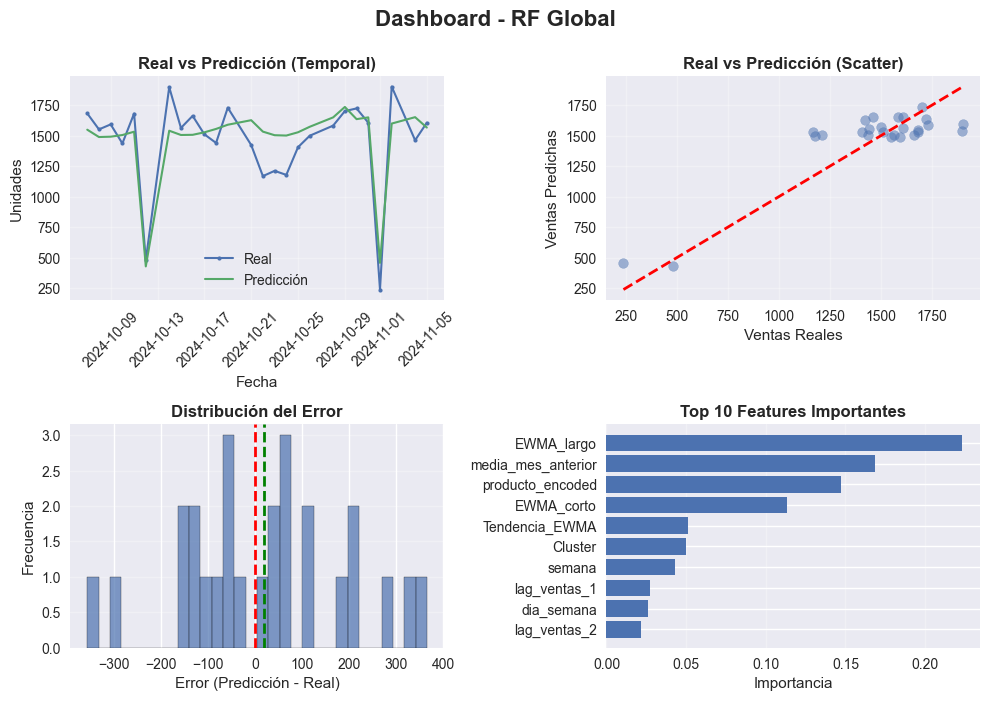

In [11]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
#df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]
df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]

dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=best_rf,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - RF Global',
        figsize=(10, 7)
        )


# Random Forest por Cluster


📍 MODELO 2: RANDOM FOREST POR CLUSTER

🔄 Entrenando modelo para Cluster 0...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        0     None 1.8138 2.5627 0.1078     39.66     125.54 0.7367    93.94

🏆 Mejor modelo: RF (RMSE: 2.5627)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        0     None 1.8138 2.5627 0.1078     39.66     125.54 0.7367    93.94

🏆 Mejor modelo: RF (RMSE: 2.5627)


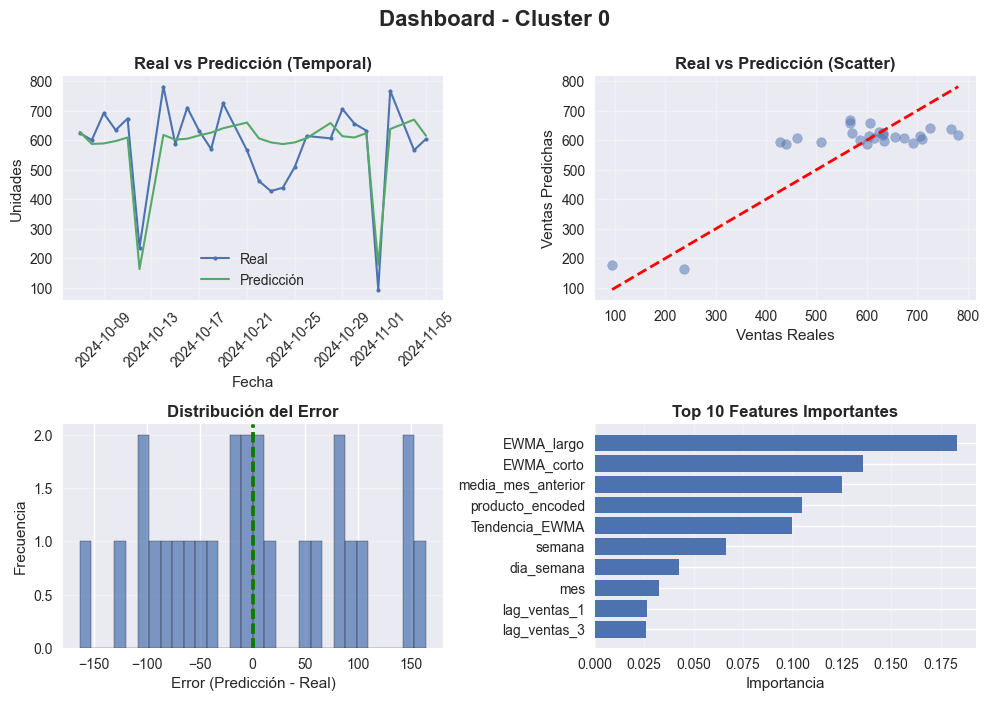


🔄 Entrenando modelo para Cluster 1...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        1     None 2.8095 3.6075 0.1344     56.18      98.59  0.721    73.68

🏆 Mejor modelo: RF (RMSE: 3.6075)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        1     None 2.8095 3.6075 0.1344     56.18      98.59  0.721    73.68

🏆 Mejor modelo: RF (RMSE: 3.6075)


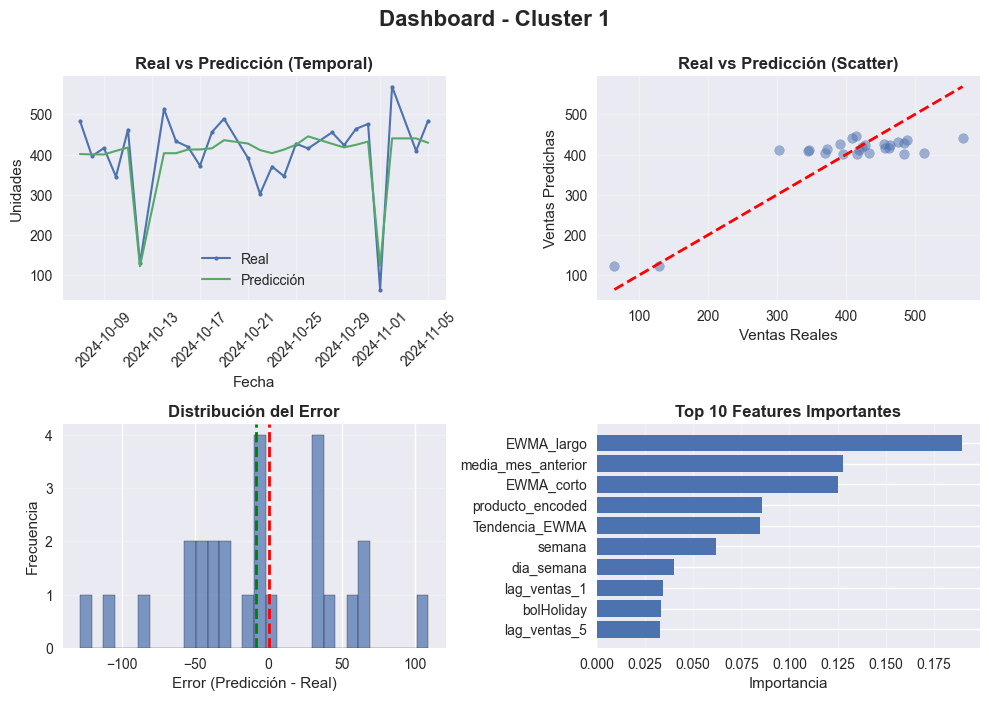


🔄 Entrenando modelo para Cluster 2...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        2     None 3.7509 5.1586 0.1776     76.63      80.98 0.7174    65.32

🏆 Mejor modelo: RF (RMSE: 5.1586)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        2     None 3.7509 5.1586 0.1776     76.63      80.98 0.7174    65.32

🏆 Mejor modelo: RF (RMSE: 5.1586)


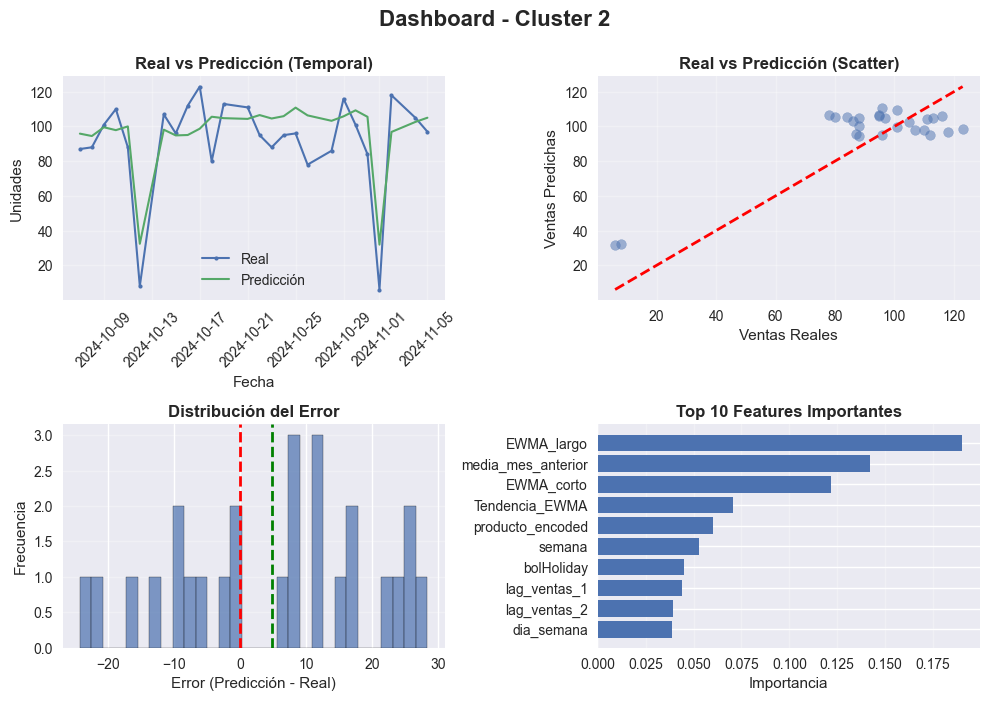


🔄 Entrenando modelo para Cluster 3...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        3     None 1.0969 1.7352 -0.0089     54.26     168.53 0.7786   135.07

🏆 Mejor modelo: RF (RMSE: 1.7352)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster        3     None 1.0969 1.7352 -0.0089     54.26     168.53 0.7786   135.07

🏆 Mejor modelo: RF (RMSE: 1.7352)


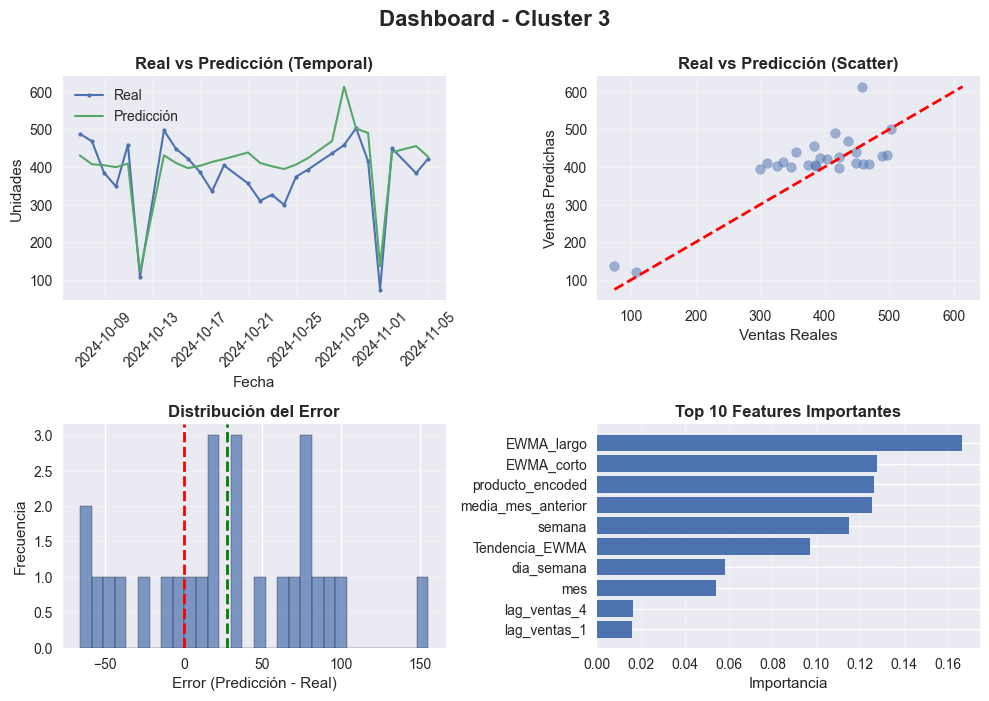

In [12]:
# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 2: RANDOM FOREST POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
    
    # Entrenar
    rf_cluster = RandomForestRegressor(
        **study_rf.best_params,
        random_state=42,
        n_jobs=-1
)
    
    rf_cluster.fit(X_train_c, y_train_c)
    y_pred_c = rf_cluster.predict(X_test_c)
    
    # modelos_cluster[cluster] = rf_cluster
    
    # Calcular métricas y GUARDAR
    metricas_cluster = calcular_metricas(
        y_test_c, y_pred_c,
        algoritmo="RF", ndetalle='Cluster', cluster=cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
    # Calcular métricas por producto top en cada cluster
    top_productos = obtener_top_productos_por_cluster(
        df=train_cluster,
        col_ventas='udsVenta',
        col_cluster='Cluster',
        col_producto='producto',
        n_productos=2
    ) 
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (test_cluster['producto'] == producto)
        y_test_prod = y_test_c[idx_producto]
        y_test_pred_prod = y_pred_c[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='RF',
            ndetalle='Cluster', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
    
    resumen_metricas([metricas_cluster])
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]
    
    dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=rf_cluster,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - Cluster {cluster}',
        figsize=(10, 7)
        )
  


# Random Forest por top 2 productos de ventas por cluster


📍 MODELO 3: RANDOM FOREST POR PRODUCTO TOP (2 POR CLUSTER)

🎯 CLUSTER 0 - Top 2 productos

🔄 Entrenando modelo para Producto 413 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        0       413 1.7011 2.1501 0.0449     35.58     104.99 0.7527     81.9

🏆 Mejor modelo: RF (RMSE: 2.1501)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        0       413 1.7011 2.1501 0.0449     35.58     104.99 0.7527     81.9

🏆 Mejor modelo: RF (RMSE: 2.1501)


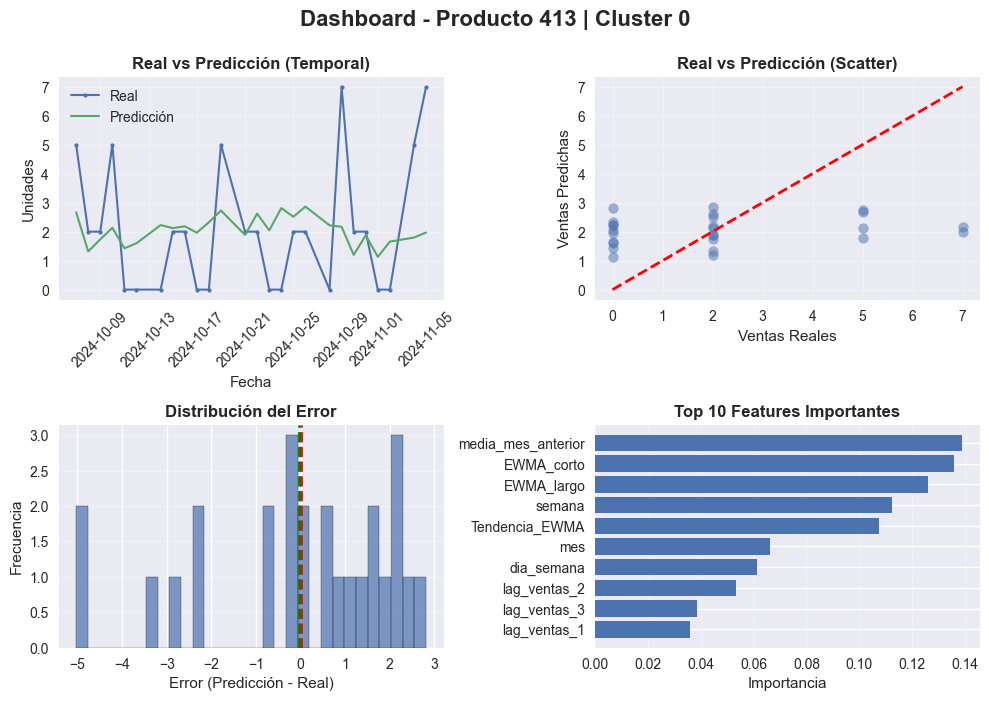


🔄 Entrenando modelo para Producto 294 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto   MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        0       294 2.554 3.2062 -0.2888      60.0     139.03 0.7387   138.34

🏆 Mejor modelo: RF (RMSE: 3.2062)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto   MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        0       294 2.554 3.2062 -0.2888      60.0     139.03 0.7387   138.34

🏆 Mejor modelo: RF (RMSE: 3.2062)


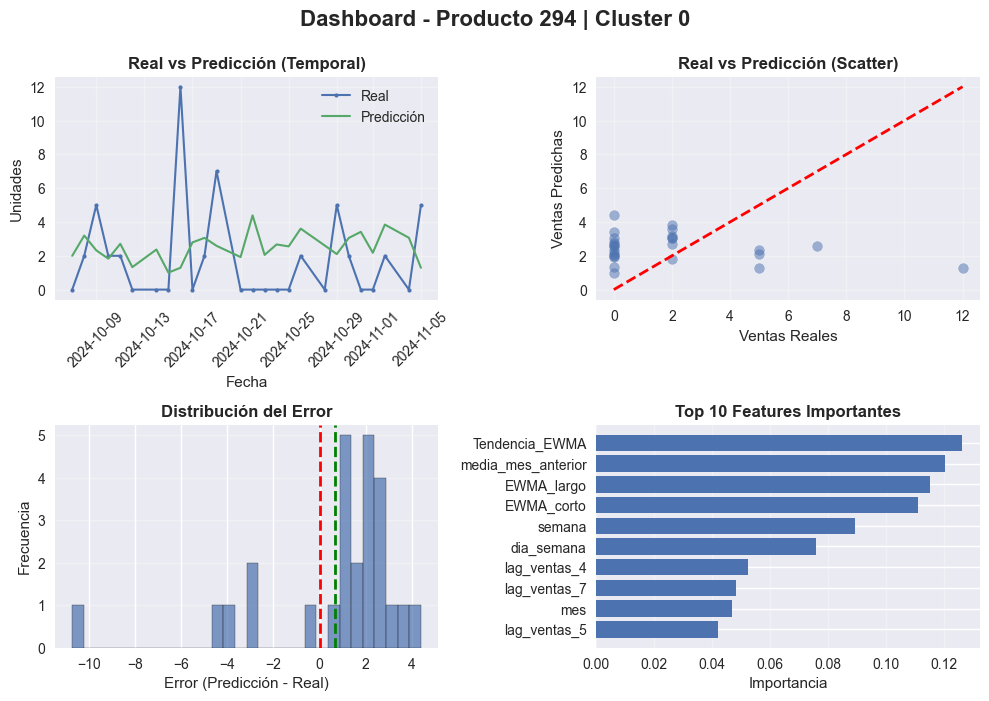


🎯 CLUSTER 1 - Top 2 productos

🔄 Entrenando modelo para Producto 144 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        1       144 4.3231 5.3744 -0.1244      85.7      88.82 0.8033    76.46

🏆 Mejor modelo: RF (RMSE: 5.3744)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        1       144 4.3231 5.3744 -0.1244      85.7      88.82 0.8033    76.46

🏆 Mejor modelo: RF (RMSE: 5.3744)


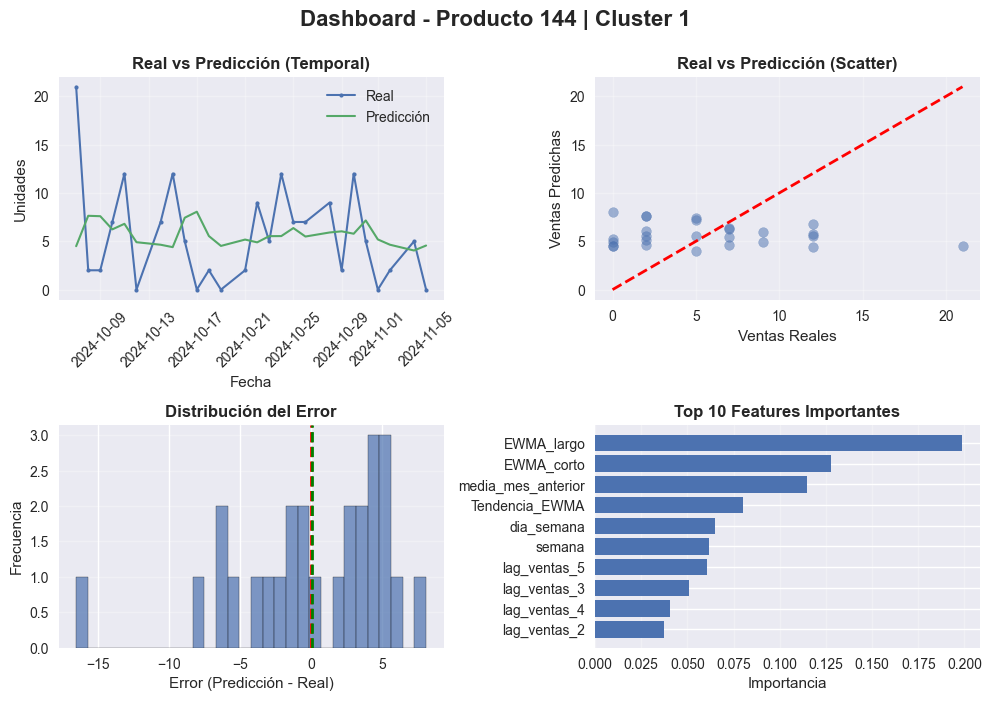


🔄 Entrenando modelo para Producto 41 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        1        41 3.6991 4.7885 -0.1245     60.76      68.18 0.8174    55.92

🏆 Mejor modelo: RF (RMSE: 4.7885)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        1        41 3.6991 4.7885 -0.1245     60.76      68.18 0.8174    55.92

🏆 Mejor modelo: RF (RMSE: 4.7885)


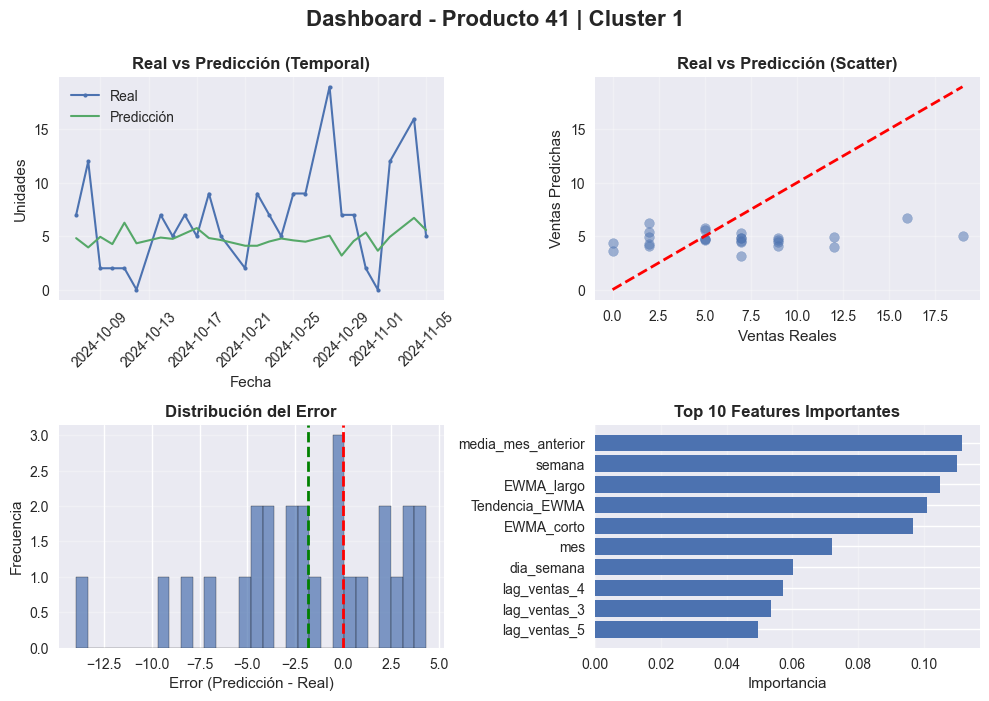


🎯 CLUSTER 2 - Top 2 productos

🔄 Entrenando modelo para Producto 1 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        2         1 8.0914 11.4105 -0.0493    114.21      71.55 0.7184    68.53

🏆 Mejor modelo: RF (RMSE: 11.4105)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        2         1 8.0914 11.4105 -0.0493    114.21      71.55 0.7184    68.53

🏆 Mejor modelo: RF (RMSE: 11.4105)


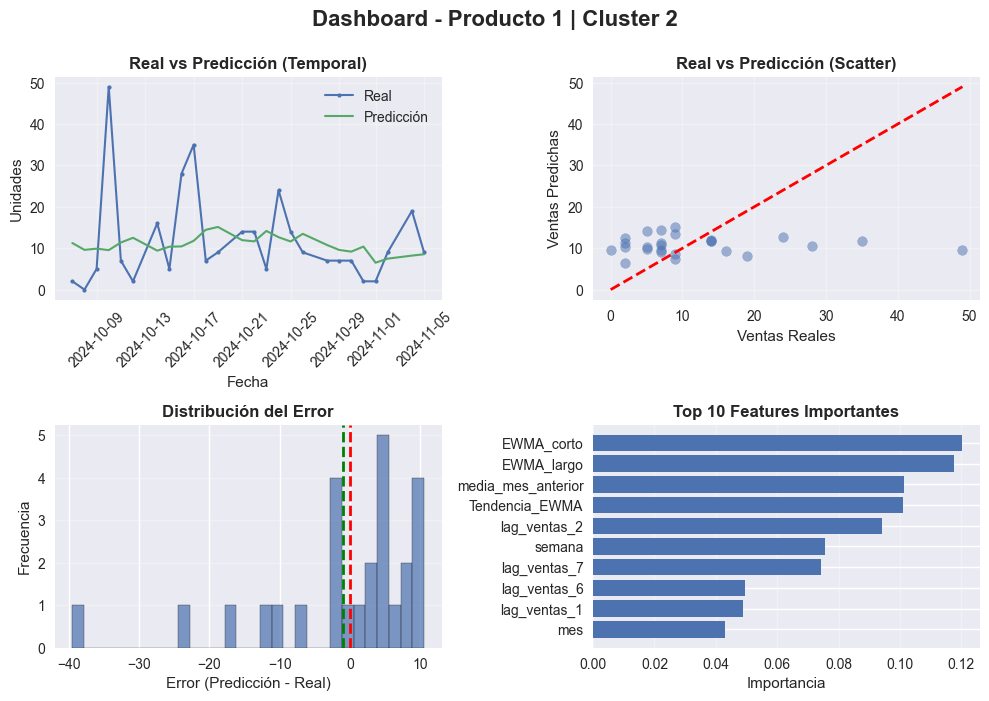


🔄 Entrenando modelo para Producto 2 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        2         2 3.9314 4.7949 -0.1246     85.25      68.45 0.6662    62.33

🏆 Mejor modelo: RF (RMSE: 4.7949)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        2         2 3.9314 4.7949 -0.1246     85.25      68.45 0.6662    62.33

🏆 Mejor modelo: RF (RMSE: 4.7949)


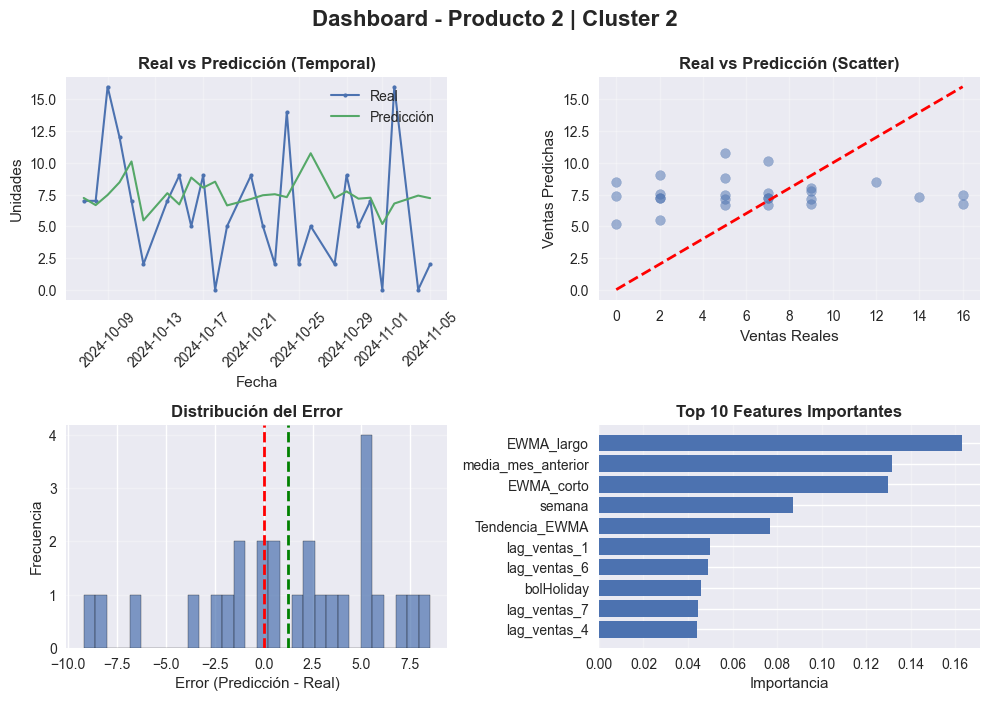


🎯 CLUSTER 3 - Top 2 productos

🔄 Entrenando modelo para Producto 257 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto   MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        3       257 0.831 1.2211 -0.1238     65.92     182.64 0.8309    166.2

🏆 Mejor modelo: RF (RMSE: 1.2211)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto   MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        3       257 0.831 1.2211 -0.1238     65.92     182.64 0.8309    166.2

🏆 Mejor modelo: RF (RMSE: 1.2211)


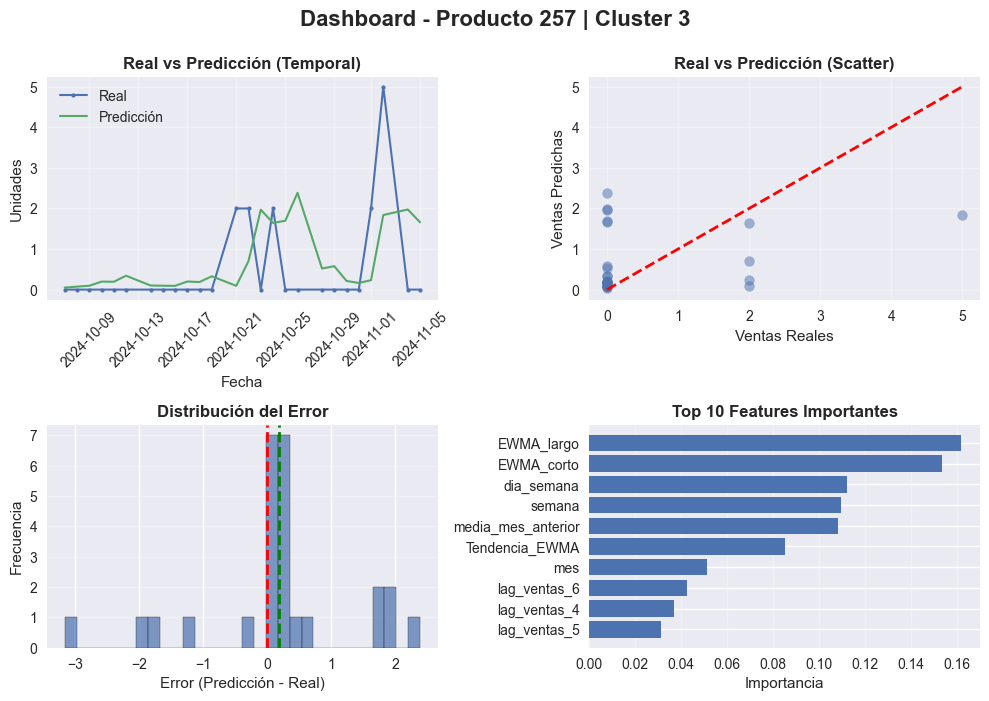


🔄 Entrenando modelo para Producto 314 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        3       314 0.4861 0.4969 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: RF (RMSE: 0.4969)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF Producto        3       314 0.4861 0.4969 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: RF (RMSE: 0.4969)


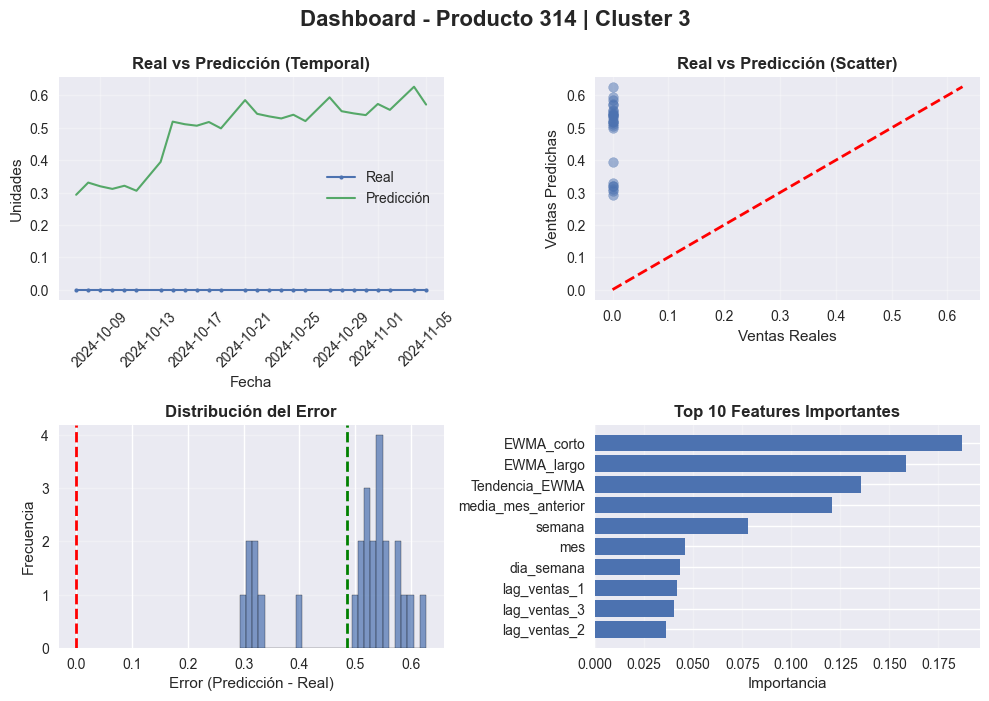


✅ Modelos por producto completados: 8 modelos entrenados


In [13]:
# ============================================================================
# 3. MODELOS POR PRODUCTO TOP (2 POR CLUSTER)
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 3: RANDOM FOREST POR PRODUCTO TOP (2 POR CLUSTER)")
print("="*100)

modelos_producto = {}

# Obtener los 2 productos top por cluster
productos_top_cluster = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

# Iterar por cada cluster y sus productos top
for cluster, productos in productos_top_cluster.items():
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {cluster} - Top {len(productos)} productos")
    print(f"{'='*100}")
    
    for producto in productos:
        print(f"\n🔄 Entrenando modelo para Producto {producto} (Cluster {cluster})...")
        
        # Filtrar datos por cluster y producto
        train_prod = df_train[(df_train['Cluster'] == cluster) & (df_train['producto'] == producto)]
        test_prod = df_test[(df_test['Cluster'] == cluster) & (df_test['producto'] == producto)].dropna()
        
        # Preparar características y target
        X_train_p = train_prod[FEATURES]
        y_train_p = train_prod[TARGET]
        X_test_p = test_prod[FEATURES]
        y_test_p = test_prod[TARGET]
        
        # Entrenar modelo con los mejores hiperparámetros de Optuna
        rf_producto = RandomForestRegressor(
            **study_rf.best_params,
            random_state=42,
            n_jobs=-1
        )
        
        rf_producto.fit(X_train_p, y_train_p)
        y_pred_p = rf_producto.predict(X_test_p)
        
        # Guardar modelo
        modelos_producto[f"C{cluster}_P{producto}"] = rf_producto
        
        # Calcular métricas y GUARDAR
        metricas_producto = calcular_metricas(
            y_test_p, y_pred_p,
            algoritmo="RF",
            ndetalle='Producto', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
        resumen_metricas([metricas_producto])
                
        # Preparar datos para visualización
        test_prod_pred = test_prod.copy()
        test_prod_pred['prediccion'] = y_pred_p
        test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
        test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
        test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / (test_prod_pred[TARGET] + 1e-10)) * 100
        test_prod_pred = test_prod_pred.sort_values('idSecuencia')
        
        # Dashboard de predicción
        dashboard_prediccion(
            df=test_prod_pred,
            col_fecha='idSecuencia',
            col_real=TARGET,
            col_pred='prediccion',
            modelo=rf_producto,
            feature_names=FEATURES,
            titulo_principal=f'Dashboard - Producto {producto} | Cluster {cluster}',
            figsize=(10, 7)
            )

print(f"\n{'='*100}")
print(f"✅ Modelos por producto completados: {len(modelos_producto)} modelos entrenados")
print(f"{'='*100}")


# Resumen final

In [14]:

# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

import plotly.express as px

print("\n" + "="*100)
print("🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS")
print("="*100)

if todas_metricas:
    # Tabla completa de métricas con metadatos
    print("\n📊 Resumen de todas las métricas (todas las columnas):")
    df_comparacion_final = pd.DataFrame(todas_metricas).copy()

    # Asegurar columnas y ordenar por Algoritmo y NDetalle (y RMSE ascendente dentro)
    columnas = [
        'Algoritmo', 'NDetalle', 'Cluster', 'Producto',
        'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)', 'RMSSE', 'MAE (%)'
    ]
    cols_exist = [c for c in columnas if c in df_comparacion_final.columns]

    # Reemplazar inf por NaN para ordenar correctamente
    df_comparacion_final = df_comparacion_final.replace([np.inf, -np.inf], np.nan)

    # Orden: Algoritmo, NDetalle, RMSE
    orden_cols = [c for c in ['Algoritmo', 'NDetalle', 'RMSE'] if c in df_comparacion_final.columns]
    df_comparacion_final = df_comparacion_final.sort_values(orden_cols, ascending=[True, True, True])

    print(df_comparacion_final[cols_exist].to_string(index=False))

    # Resúmenes por NDetalle
    print("\n" + "="*100)
    print("📊 ANÁLISIS POR CATEGORÍAS DE MODELOS (NDetalle)")
    print("="*100)

    for nivel in ['Global', 'Cluster', 'Producto']:
        dfn = df_comparacion_final[df_comparacion_final['NDetalle'] == nivel]
        print(f"\n🔹 {nivel.upper()}:")
        if len(dfn) > 0:
            cols_nivel = ['Algoritmo', 'NDetalle', 'Cluster', 'Producto', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)']
            print(dfn[[c for c in cols_nivel if c in dfn.columns]].to_string(index=False))
            print(f"\n   Promedio RMSE: {dfn['RMSE'].mean():.2f}")
            if nivel == 'Cluster':
                print(f"   Mejor cluster: {dfn.loc[dfn['RMSE'].idxmin(), 'Cluster']} (RMSE: {dfn['RMSE'].min():.2f})")
                print(f"   Peor cluster: {dfn.loc[dfn['RMSE'].idxmax(), 'Cluster']} (RMSE: {dfn['RMSE'].max():.2f})")
            if nivel == 'Producto':
                best_idx = dfn['RMSE'].idxmin(); worst_idx = dfn['RMSE'].idxmax()
                print(f"   Mejor producto: C{dfn.loc[best_idx, 'Cluster']} P{dfn.loc[best_idx, 'Producto']} (RMSE: {dfn['RMSE'].min():.2f})")
                print(f"   Peor producto: C{dfn.loc[worst_idx, 'Cluster']} P{dfn.loc[worst_idx, 'Producto']} (RMSE: {dfn['RMSE'].max():.2f})")

    # Mejor modelo general (por RMSE)
    print("\n" + "="*100)
    print("🥇 MEJOR MODELO GENERAL (RMSE mínimo)")
    print("="*100)
    mejor_idx = df_comparacion_final['RMSE'].idxmin()
    mejor_modelo = df_comparacion_final.loc[mejor_idx]

    print(f"\n🏆 {mejor_modelo['Algoritmo']} | {mejor_modelo['NDetalle']}")
    print(f"   Cluster:    {mejor_modelo.get('Cluster', None)}")
    print(f"   Producto:   {mejor_modelo.get('Producto', None)}")
    print(f"   MAE:        {mejor_modelo['MAE']:.2f}")
    print(f"   MSE:        {mejor_modelo['MSE']:.2f}")
    print(f"   RMSE:       {mejor_modelo['RMSE']:.2f}")
    print(f"   R²:         {mejor_modelo['R2']:.4f}")
    print(f"   MAPE:       {mejor_modelo['MAPE (%)']:.2f}%")
    print(f"   SMAPE:      {mejor_modelo['SMAPE (%)']:.2f}%")
    print(f"   RMSSE:      {mejor_modelo['RMSSE']:.2f}")
    print(f"   MAE (%):    {mejor_modelo['MAE (%)']:.2f}")

else:
    print("\n⚠️  No se generaron métricas para ningún modelo")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*100)
print(f"\n📊 Total de modelos evaluados: {len(todas_metricas)}")
print(f"   - Modelos globales: {len([m for m in todas_metricas if m.get('NDetalle') == 'Global'])}")
print(f"   - Modelos por cluster: {len([m for m in todas_metricas if m.get('NDetalle') == 'Cluster'])}")
print(f"   - Modelos por producto: {len([m for m in todas_metricas if m.get('NDetalle') == 'Producto'])}")



🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas (todas las columnas):
Algoritmo NDetalle  Cluster  Producto    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
       RF  Cluster      3.0     314.0 0.4790   0.2427  0.4926  0.0000       NaN     200.00    NaN      NaN
       RF  Cluster      3.0     257.0 0.9060   1.4121  1.1883 -0.0642     71.06     183.46 0.8086   181.21
       RF  Cluster      3.0       NaN 1.0969   3.0109  1.7352 -0.0089     54.26     168.53 0.7786   135.07
       RF  Cluster      0.0     413.0 1.7652   4.8125  2.1937  0.0057     35.37     102.73 0.7680    84.99
       RF  Cluster      0.0       NaN 1.8138   6.5673  2.5627  0.1078     39.66     125.54 0.7367    93.94
       RF  Cluster      0.0     294.0 2.2717   8.7106  2.9514 -0.0921     42.06     131.38 0.6800   123.05
       RF  Cluster      1.0       NaN 2.8095  13.0140  3.6075  0.1344     56.18      98.59 0.7210    73.68
       RF  Cluster      1.0      41.0

# Salvar resultados

In [15]:
# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_rf.csv', index=False)